# Exploratory Data Analysis & Intro

## Goal
1. Investigate top-paying roles and skills for Data Analysts, Data Scientists, and Data Engineers.
2. Use Python to explore a real-live dataset on job postings.
3. For job-seekers: use these insights to help find the best job opportunities in Australia.


## Questions to Answer

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demand skills trending for Data Analysts, Data Scientists, and Data Engineers?
3. How well do jobs and skills pay for these roles?
4. What is the most optimal skill to learn for these roles? (High Demand AND High Paying)

I'll be focusing on Data Analyst, Data Scientist, and Data Engineer roles in Australia.


## Exploratory Data Analysis for all Data Roles

### Roles to Explore

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

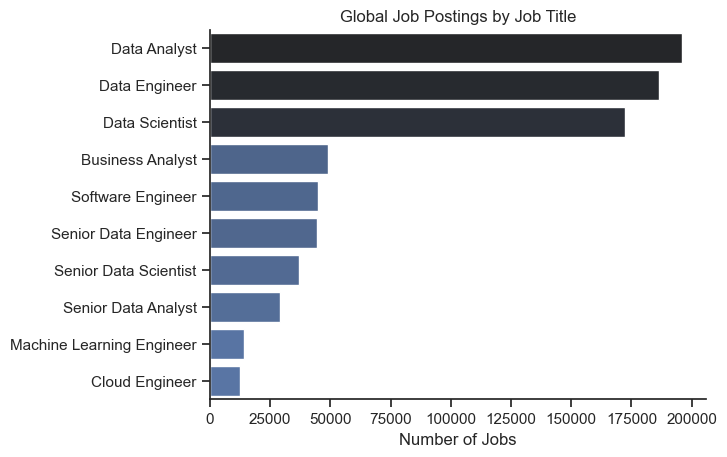

In [2]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Global Job Postings by Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


### Countries to Explore

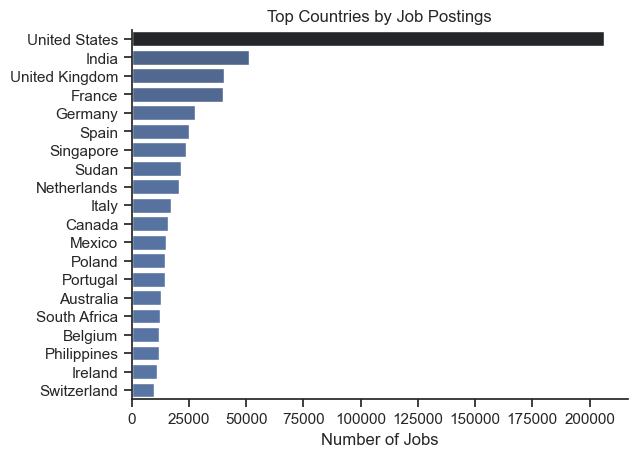

In [3]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Top Countries by Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


### Companies to Explore

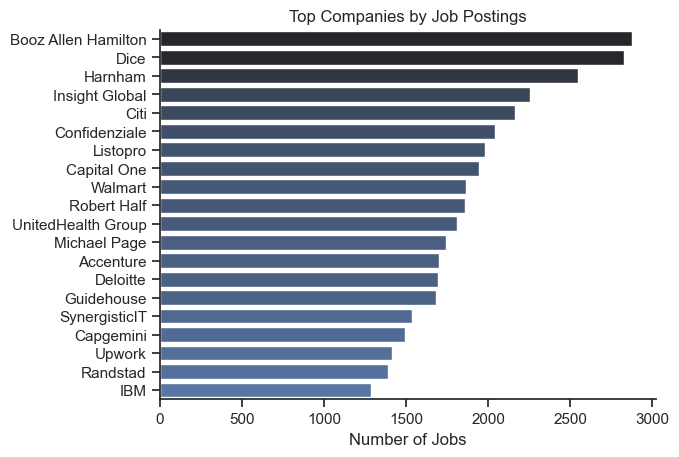

In [4]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Top Companies by Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


### Job Opportunities

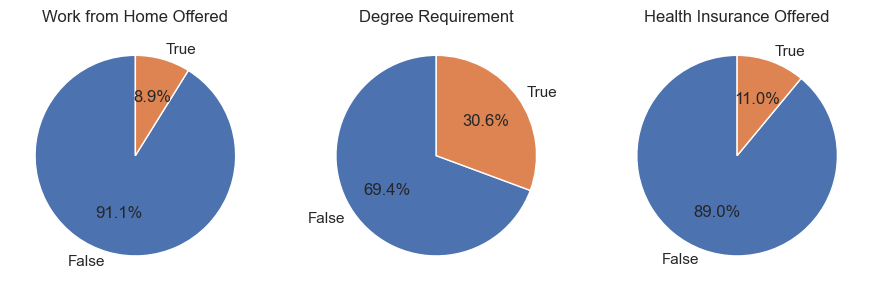

In [5]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

## Exploratory Data Analysis for Data Roles
Focusing on Data Analysts, Data Scientists, and Data Engineers in Australia.


In [6]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter for Target Roles and Countries

In [7]:
# Filter for Data Analyst, Data Scientist, Data Engineer in Australia
countries = ['Australia']
roles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

df_filtered = df[
    (df['job_country'].isin(countries)) &
    (df['job_title_short'].isin(roles))
].copy()


### Locations to Explore:

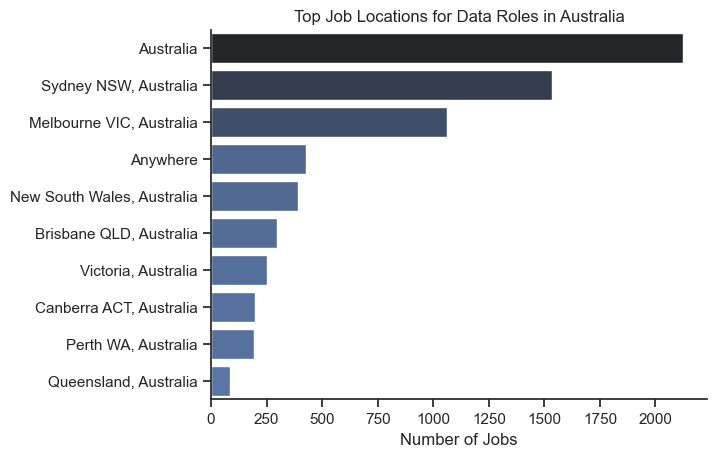

In [8]:
df_plot = df_filtered['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Top Job Locations for Data Roles in Australia')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


### Job Opportunities

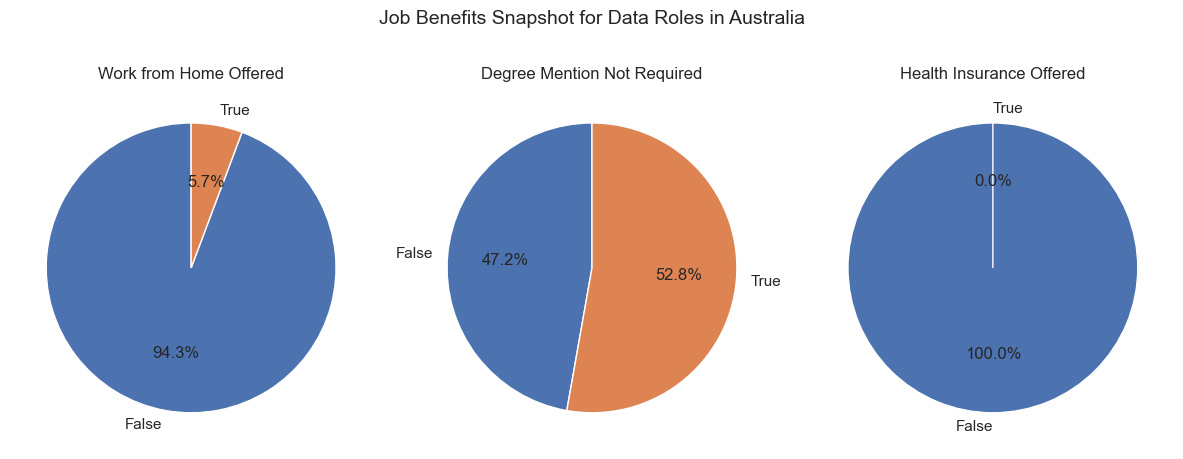

In [9]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Mention Not Required',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_filtered[column].value_counts().reindex([False, True], fill_value=0), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

fig.suptitle('Job Benefits Snapshot for Data Roles in Australia', fontsize=14)
plt.tight_layout()
plt.show()


### Companies to Explore:

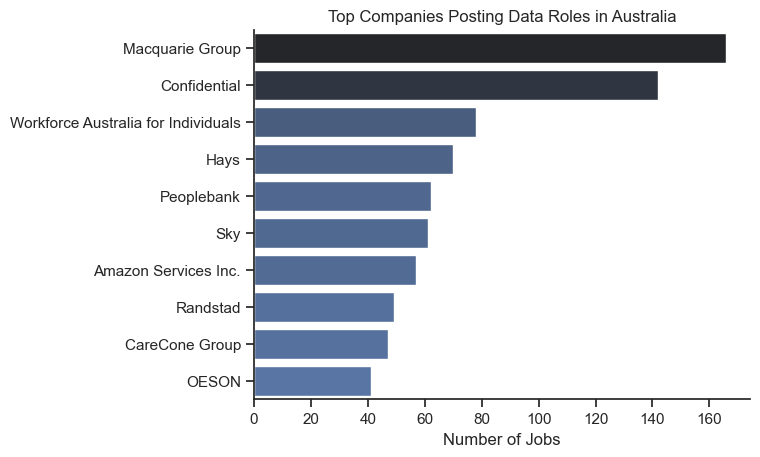

In [10]:
df_plot = df_filtered['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Top Companies Posting Data Roles in Australia')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()
